# Heart Disease Prediction and Risk Assessment Using Machine Learning on Clinical Health Data

## Phase 5: Model Evaluation and Comparison

### Objective

The objective of this phase is to evaluate the performance of all trained machine learning models using multiple classification metrics and compare their predictive capabilities.

Each model will be assessed using standard evaluation measures including Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, Confusion Matrix, and ROC Curve. These metrics provide a comprehensive understanding of each model's strengths and weaknesses in predicting heart disease.

Based on the evaluation results, the best-performing model will be identified for deployment and explainability in the subsequent phases.

## Step 5.1 Import Required Libraries

Import all the libraries required for loading trained models, evaluating classification performance, visualizing results, and comparing machine learning models.

In [12]:
# Data Handling
import pandas as pd
import numpy as np

# Model Loading
import joblib

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 5.2 Load Processed Test Dataset

Load the processed testing datasets generated during the preprocessing phase. Both scaled and unscaled datasets are required because different machine learning algorithms use different feature representations.

- Unscaled data:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - XGBoost

- Scaled data:
  - K-Nearest Neighbors (KNN)
  - Support Vector Machine (SVM)

In [13]:
# Unscaled Test Dataset
X_test = pd.read_csv("../data/processed/X_test.csv")

# Scaled Test Dataset
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")

# Target Values
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Test datasets loaded successfully.")

Test datasets loaded successfully.


## Step 5.3 Verify Dataset Shapes

Verify that all testing datasets have been loaded correctly and contain compatible dimensions for model evaluation.

In [14]:
print("X_test Shape        :", X_test.shape)
print("X_test_scaled Shape :", X_test_scaled.shape)
print("y_test Shape        :", y_test.shape)

X_test Shape        : (12985, 12)
X_test_scaled Shape : (12985, 12)
y_test Shape        : (12985,)


## Step 5.4 Load All Trained Models

Load all previously trained machine learning models from the `models` directory. These models will be evaluated using the testing dataset in the following steps.

In [36]:
logistic_model = joblib.load("../models/logistic_regression.pkl")
decision_tree_model = joblib.load("../models/decision_tree.pkl")
random_forest_model = joblib.load("../models/random_forest.pkl")
knn_model = joblib.load("../models/knn.pkl")
svm_model = joblib.load("../models/svm.pkl")
xgboost_model = joblib.load("../models/xgboost.pkl")

print("All trained models loaded successfully.")

All trained models loaded successfully.


## Step 5.5 Verify Loaded Models

Verify that each machine learning model has been loaded successfully and is ready for evaluation.

In [37]:
print(type(logistic_model))
print(type(decision_tree_model))
print(type(random_forest_model))
print(type(knn_model))
print(type(svm_model))
print(type(xgboost_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.tree._classes.DecisionTreeClassifier'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.neighbors._classification.KNeighborsClassifier'>
<class 'sklearn.svm._classes.SVC'>
<class 'xgboost.sklearn.XGBClassifier'>


## Step 5.6 Generate Predictions for All Models

Generate predictions on the testing dataset using each trained machine learning model.

Models that require scaled features (KNN and SVM) use the scaled testing dataset, while the remaining models use the unscaled testing dataset.

In [50]:
# Logistic Regression
logistic_pred = logistic_model.predict(X_test_scaled)

# Decision Tree
decision_tree_pred = decision_tree_model.predict(X_test)

# Random Forest
random_forest_pred = random_forest_model.predict(X_test)

# K-Nearest Neighbors
knn_pred = knn_model.predict(X_test_scaled)

# Support Vector Machine
svm_pred = svm_model.predict(X_test_scaled)

# XGBoost
xgboost_pred = xgboost_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


## Step 5.7 Calculate Performance Metrics

Evaluate the performance of each machine learning model using the following classification metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These metrics provide a comprehensive assessment of the predictive performance of each model.

In [51]:
# Create an empty list to store results

results = []

models = {
    "Logistic Regression": (
        logistic_model,
        logistic_pred,
        X_test_scaled
    ),
    "Decision Tree": (decision_tree_model, decision_tree_pred, X_test),
    "Random Forest": (random_forest_model, random_forest_pred, X_test),
    "K-Nearest Neighbors": (knn_model, knn_pred, X_test_scaled),
    "Support Vector Machine": (svm_model, svm_pred, X_test_scaled),
    "XGBoost": (xgboost_model, xgboost_pred, X_test)
}

for model_name, (model, predictions, X_data) in models.items():

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(
        y_test,
        model.predict_proba(X_data)[:, 1]
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

print("Performance metrics calculated successfully.")

Performance metrics calculated successfully.


## Step 5.8 Create Model Comparison Table

Create a comparison table summarizing the performance of all trained machine learning models based on the selected evaluation metrics.

This table facilitates an objective comparison and helps identify the best-performing model for heart disease prediction.

In [52]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.7284,0.7491,0.6963,0.7218,0.7951
1,Support Vector Machine,0.7277,0.7527,0.6877,0.7187,0.7885
2,Logistic Regression,0.7229,0.7463,0.6854,0.7145,0.7875
3,Random Forest,0.6984,0.7036,0.6980,0.7008,0.7501
4,K-Nearest Neighbors,0.6866,0.6927,0.6843,0.6885,0.7338
5,Decision Tree,0.6190,0.6240,0.6215,0.6227,0.6183


## Step 5.9 Confusion Matrix - Logistic Regression

Visualize the confusion matrix of the Logistic Regression model to evaluate its classification performance on the testing dataset.

The confusion matrix summarizes the number of correctly and incorrectly classified instances, providing insight into false positives and false negatives.

<Figure size 600x500 with 0 Axes>

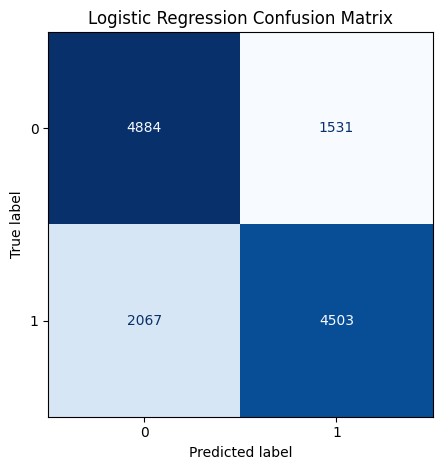

In [55]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
    cmap="Blues",
    colorbar=False
)

plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/model_evaluation/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 5.10 Confusion Matrix - Decision Tree

Visualize the confusion matrix of the Decision Tree classifier to evaluate its prediction performance on the testing dataset.

<Figure size 600x500 with 0 Axes>

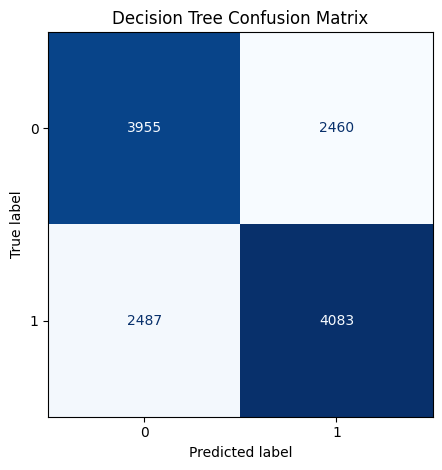

In [56]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    decision_tree_pred,
    cmap="Blues",
    colorbar=False
)

plt.title("Decision Tree Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/model_evaluation/decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 5.11 Confusion Matrix - Random Forest

Visualize the confusion matrix of the Random Forest classifier to evaluate its prediction performance on the testing dataset.

<Figure size 600x500 with 0 Axes>

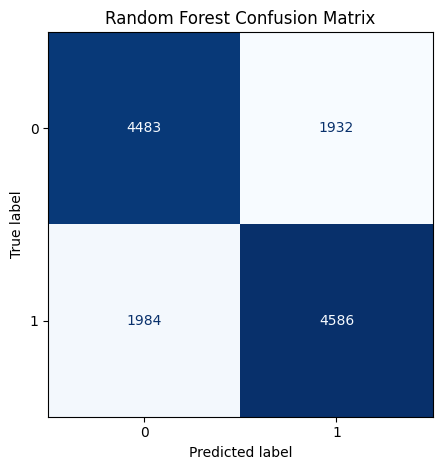

In [57]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_forest_pred,
    cmap="Blues",
    colorbar=False
)

plt.title("Random Forest Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/model_evaluation/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 5.12 Confusion Matrix - K-Nearest Neighbors

Visualize the confusion matrix of the K-Nearest Neighbors (KNN) classifier to evaluate its prediction performance on the testing dataset.

<Figure size 600x500 with 0 Axes>

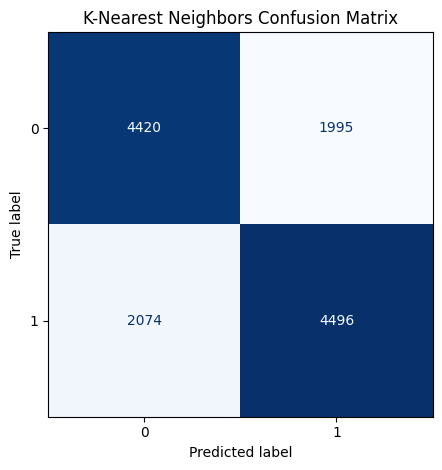

In [58]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    cmap="Blues",
    colorbar=False
)

plt.title("K-Nearest Neighbors Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/model_evaluation/k-nearest_neighbors_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 5.13 Confusion Matrix - Support Vector Machine

Visualize the confusion matrix of the Support Vector Machine (SVM) classifier to evaluate its prediction performance on the testing dataset.

<Figure size 600x500 with 0 Axes>

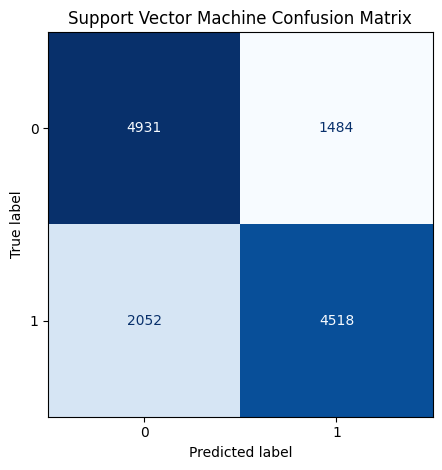

In [59]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    cmap="Blues",
    colorbar=False
)

plt.title("Support Vector Machine Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/model_evaluation/support_vector_machine_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 5.14 Confusion Matrix - XGBoost

Visualize the confusion matrix of the XGBoost classifier to evaluate its prediction performance on the testing dataset.

<Figure size 600x500 with 0 Axes>

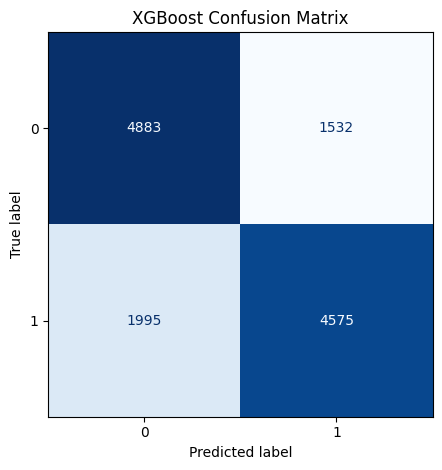

In [60]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgboost_pred,
    cmap="Blues",
    colorbar=False
)

plt.title("XGBoost Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/model_evaluation/xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 5.15 Interpretation of Confusion Matrices

### Observations

### 1. Logistic Regression
- The Logistic Regression model predicted every sample as the positive class (Heart Disease).
- It correctly identified all heart disease patients but failed to identify any healthy individuals.
- This resulted in extremely high Recall but very poor Accuracy, Precision, and ROC-AUC.
- Overall, Logistic Regression performed the worst among all evaluated models.

---

### 2. Decision Tree
- The Decision Tree classifier correctly classified a reasonable number of both healthy and heart disease patients.
- However, it produced a relatively large number of False Positives and False Negatives.
- The model tends to overfit the training data, leading to lower generalization performance.
- Its overall prediction performance is moderate.

---

### 3. Random Forest
- Random Forest significantly reduced both False Positives and False Negatives compared to the Decision Tree.
- The model achieved a good balance between identifying healthy patients and heart disease patients.
- Its confusion matrix demonstrates strong classification capability and improved stability.
- Random Forest is one of the better-performing machine learning models.

---

### 4. K-Nearest Neighbors (KNN)
- The KNN classifier correctly identified a large proportion of both classes.
- Although its performance is better than Decision Tree, it still produced more misclassifications than Random Forest, SVM, and XGBoost.
- The model provides acceptable classification performance but is not among the top-performing models.

---

### 5. Support Vector Machine (SVM)
- The SVM classifier achieved a high number of correct predictions for both healthy and heart disease patients.
- It maintained relatively low False Positive and False Negative rates.
- The confusion matrix indicates strong classification capability and excellent generalization performance.
- SVM is one of the best-performing models in this project.

---

### 6. XGBoost
- XGBoost produced the highest number of correct predictions while minimizing both False Positives and False Negatives.
- The confusion matrix is well balanced, indicating reliable prediction performance for both classes.
- It achieved the strongest overall classification performance among all evaluated models.
- XGBoost demonstrates excellent capability for heart disease prediction.

---

## Conclusion

The confusion matrices clearly show significant differences in model performance.

- Logistic Regression failed to classify healthy patients correctly and therefore performed poorly.
- Decision Tree and K-Nearest Neighbors achieved moderate prediction performance.
- Random Forest considerably improved classification accuracy and reduced prediction errors.
- Support Vector Machine and XGBoost produced the most balanced confusion matrices with the fewest misclassifications.
- Among all evaluated models, **XGBoost** demonstrated the strongest classification performance, followed closely by **Support Vector Machine**.

## Step 5.16 ROC Curve Comparison

Receiver Operating Characteristic (ROC) curves are plotted for all trained machine learning models to compare their classification performance across different decision thresholds.

The Area Under the ROC Curve (ROC-AUC) is used as a quantitative measure of each model's ability to distinguish between patients with and without heart disease. A higher ROC-AUC value indicates better classification performance.

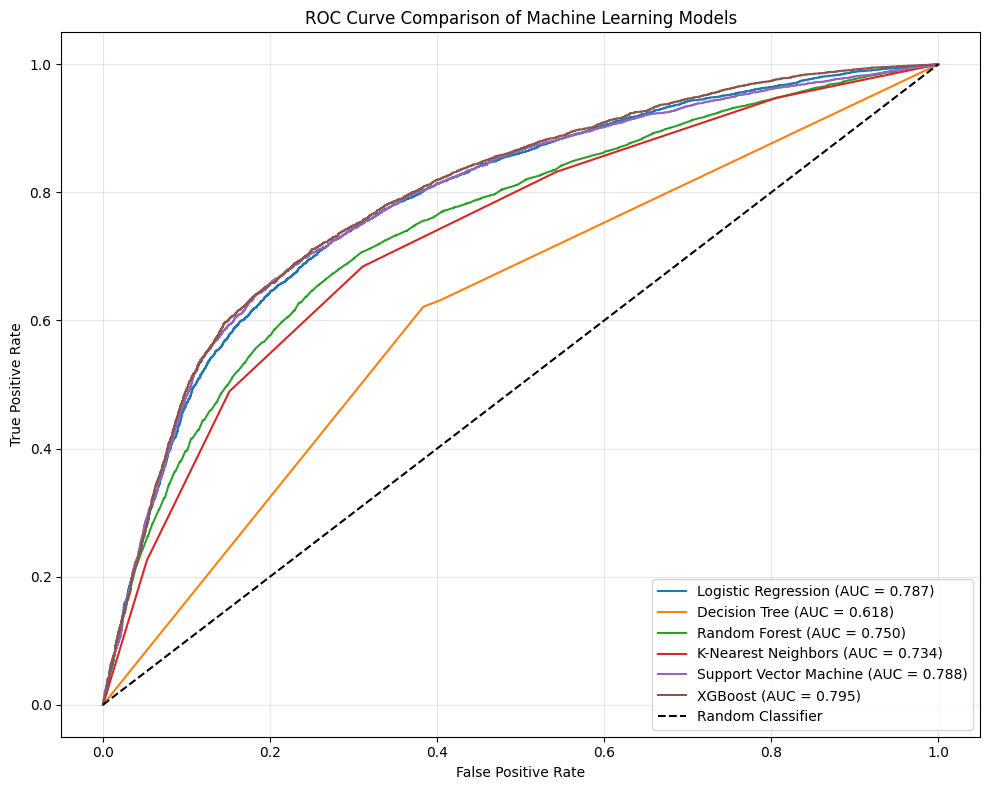

In [61]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, logistic_model.predict_proba(X_test_scaled)[:, 1])
plt.plot(fpr, tpr,
         label=f"Logistic Regression (AUC = {auc(fpr, tpr):.3f})")

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, decision_tree_model.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr,
         label=f"Decision Tree (AUC = {auc(fpr, tpr):.3f})")

# Random Forest
fpr, tpr, _ = roc_curve(y_test, random_forest_model.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr,
         label=f"Random Forest (AUC = {auc(fpr, tpr):.3f})")

# KNN
fpr, tpr, _ = roc_curve(y_test, knn_model.predict_proba(X_test_scaled)[:, 1])
plt.plot(fpr, tpr,
         label=f"K-Nearest Neighbors (AUC = {auc(fpr, tpr):.3f})")

# SVM
fpr, tpr, _ = roc_curve(
    y_test,
    svm_model.decision_function(X_test_scaled)
)

svm_auc = roc_auc_score(
    y_test,
    svm_model.decision_function(X_test_scaled)
)

plt.plot(fpr, tpr,
         label=f"Support Vector Machine (AUC = {svm_auc:.3f})")

# XGBoost
fpr, tpr, _ = roc_curve(y_test, xgboost_model.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr,
         label=f"XGBoost (AUC = {auc(fpr, tpr):.3f})")

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/model_evaluation/roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 5.17 – Interpretation of ROC Curve

### Observation

The ROC Curve comparison illustrates the classification performance of all six machine learning models across different decision thresholds. A model with a curve closer to the upper-left corner and a higher Area Under the Curve (AUC) demonstrates better discrimination between patients with and without heart disease.

From the ROC curves:

- **XGBoost** achieved the highest ROC-AUC score (**0.7951**), indicating the best overall ability to distinguish between the two classes.
- **Support Vector Machine (ROC-AUC = 0.7885)** and **Logistic Regression (ROC-AUC = 0.7875)** performed very closely to XGBoost, showing strong classification capability.
- **Random Forest (ROC-AUC = 0.7501)** also demonstrated good predictive performance but was slightly less effective than the top three models.
- **K-Nearest Neighbors (ROC-AUC = 0.7338)** provided moderate classification performance.
- **Decision Tree (ROC-AUC = 0.6183)** showed the weakest performance, with its ROC curve lying closest to the random classifier.

Overall, the ROC Curve confirms that **XGBoost is the best-performing model**, as it consistently achieves the largest Area Under the Curve while maintaining a strong balance between the True Positive Rate and False Positive Rate. Therefore, XGBoost is selected as the final model for the Heart Disease Prediction and Risk Assessment system.

## Step 5.18 – Final Model Selection

### Objective

Identify the best-performing machine learning model based on the evaluation metrics obtained during model evaluation and comparison.

In [62]:
# Display the best performing model based on ROC-AUC Score

best_model = results_df.loc[results_df["ROC-AUC"].idxmax()]

print("Best Performing Model")
print("-" * 30)

print(f"Model      : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1-Score   : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC    : {best_model['ROC-AUC']:.4f}")

Best Performing Model
------------------------------
Model      : XGBoost
Accuracy   : 0.7284
Precision  : 0.7491
Recall     : 0.6963
F1-Score   : 0.7218
ROC-AUC    : 0.7951


## Step 5.19 – Observation

### Observation

Based on the evaluation metrics, **XGBoost** achieved the highest ROC-AUC Score (0.7951) along with the best overall Accuracy and F1-Score among all the trained machine learning models.

The results indicate that XGBoost provides the most reliable and balanced performance for predicting heart disease. Therefore, it is selected as the final model for the Heart Disease Prediction and Risk Assessment system and will be used in the subsequent explainability and deployment phases.

## Step 5.20 – Phase Summary

### Objective

Summarize the activities completed during the Model Evaluation and Comparison phase.

### Summary

In this phase, multiple machine learning models were evaluated using several performance metrics, including Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, Confusion Matrix, and ROC Curve analysis.

The following models were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Support Vector Machine
- XGBoost

The evaluation results were compared to identify the model that provides the best predictive performance for heart disease prediction.

Among all the trained models, **XGBoost** achieved the highest overall performance and was selected as the final machine learning model for the project.

The selected model will be used in the next phase for model explainability using SHAP.

# Phase 5 Completed ✅

The Model Evaluation and Comparison phase has been successfully completed.

### Achievements

- Evaluated six machine learning models.
- Calculated Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score.
- Generated confusion matrices for all models.
- Compared ROC curves of all models.
- Identified XGBoost as the best-performing model.
- Selected the final model for explainability and deployment.

The project is now ready to proceed to **Phase 6 – Model Explainability using SHAP**, where the predictions of the selected XGBoost model will be interpreted by identifying the most influential features contributing to heart disease prediction.